<a href="https://colab.research.google.com/github/FinestMaximus/mrkt_screener/blob/main/Screening_Stocks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Getting Requirements**

In [2]:
! pip install matplotlib yfinance pandas mplfinance marketprofile plotly

  Using cached mplfinance-0.12.10b0-py3-none-any.whl (75 kB)
  Using cached MarketProfile-0.2.0-py3-none-any.whl (5.6 kB)


# **Imports**

In [3]:
from datetime import datetime, timedelta

import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go

import mplfinance as mpf
import numpy as np
import pandas as pd
import pandas_datareader as pdr
import yfinance as yf
from IPython.display import Markdown, display
from plotly.subplots import make_subplots

from market_profile import MarketProfile


# **Initial Companies**

In [4]:
companies = ['AMZN', 'GOOG', 'WMT', 'TSLA', 'META', 'NVDA', 'GOLD', 'GSAT', 'AMD',
             'ASML', 'BHP', 'NFLX', 'AAPL', 'AMUN.PA', 'STM', 'LUV', 'TKA.DE', 'IFX.DE',
             'ERA.PA', 'VK.PA', 'MTTR', 'EDF', 'PLUG', 'ASTR', 'NIO', 'LCID', 'SGML', 'U',
             'OKTA', 'SSSS', 'PANW', 'TDOC', 'DARK.L', 'PL', 'IRDM', 'JBLU', 'BTC-USD', 'ETH-USD',
             'DOGE-USD', 'TSM', 'FSLR', 'RAYS', 'ICLN', 'ENB', 'NEE', 'ALB', 'DIS', 'TMUS',
             'VZ', 'CMCSA', 'T', 'NTES', 'AMX', 'SPIR', 'ASTS', 'SPCE', 'LUNR', 'LLAP', 'RKLB',
             'STLA', 'MSFT']

# '2222.SR'ARAMCO

# **Parametters**

In [5]:
interval_dates = '3mo' ### each candle is a quarter
days_history = 365*5 ### looking 5 years back, and 5 years forward
eps_threshold = 5 ### interested in high revenue companies

# **Data fetching and preparation**

In [10]:
def fetch_historical_data(ticker, start_date, end_date, period=None, interval=interval_dates):
    try:
        if period:
            data = ticker.history(period=period, interval=interval)
        else:
            data = ticker.history(start=start_date, end=end_date, interval=interval)
        return data
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        return pd.DataFrame()  # Return an empty DataFrame

def fetch_data(companies):
    tickers = yf.Tickers(' '.join(companies))
    start_date_str, end_date_str = get_date_range()
    metrics = {
        'eps_values': [],
        'pe_values': [],
        'market_caps': [],
        'company_labels': [],
        'price_diff': {}
    }
    industries = classify_by_industry(tickers)

    price_diff = calculate_price_diff(companies)
    metrics['price_diff'] = price_diff

    for company in companies:
        ticker = tickers.tickers[company]
        data = fetch_historical_data(ticker, start_date_str, end_date_str)
        if not data.empty:
            populate_metrics(ticker, metrics)

    return industries, metrics

def calculate_price_diff(companies):
    tickers = yf.Tickers(' '.join(companies))
    price_diff = {}  # Store price difference info here

    for company in companies:
        ticker = tickers.tickers[company]
        hist = fetch_historical_data(ticker, None, None, period="1y")
        if not hist.empty:
            today_price = hist['Close'].iloc[-1]
            high_52week = max(hist['High'])
            low_52week = min(hist['Low'])
            high_percent_diff = ((today_price - high_52week) / high_52week) * 100
            low_percent_diff = ((today_price - low_52week) / low_52week) * 100
            price_diff[company] = {'high_diff': -1 * high_percent_diff, 'low_diff': low_percent_diff}

    return price_diff

def populate_metrics(ticker, metrics):
    stock_info = ticker.info
    eps = stock_info.get('trailingEps', 0)
    pe = stock_info.get('trailingPE', 0)
    market_cap = stock_info.get('marketCap', 0)

    if eps and pe:
        metrics['eps_values'].append(eps)
        metrics['pe_values'].append(pe)
        metrics['market_caps'].append(market_cap)
        metrics['company_labels'].append(ticker.ticker)

def get_date_range(days_back=days_history):
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days_back)
    return start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')

def classify_by_industry(tickers):
    industries = {}
    for ticker in tickers.tickers.values():
        try:
            sector = ticker.info['sector']
        except KeyError:
            continue
        industries.setdefault(sector, []).append(ticker)
    return industries

def calculate_market_profile(data):
    mp = MarketProfile(data)
    mp_slice = mp[data.index.min():data.index.max()]

    # Access the attributes you're interested in
    va_high, va_low = mp_slice.value_area
    poc_price = mp_slice.poc_price  # Point of control price
    profile_range = mp_slice.profile_range

    return va_high, va_low, poc_price, profile_range

def plot_sector_distribution_interactive(industries):
    # Calculate total tickers per sector
    sector_counts = {sector: len(tickers) for sector, tickers in industries.items()}

    # Data for plotting
    labels = list(sector_counts.keys())
    sizes = list(sector_counts.values())

    # Create the pie chart
    fig = go.Figure(data=[go.Pie(labels=labels, values=sizes, hole=.3)])

    # Customizing the plot
    fig.update_layout(
        title_text="Interactive Ticker Distribution by Sector",
        # Add annotations in the center of the donut pies.
        annotations=[dict(text='Sectors', x=0.50, y=0.5, font_size=20, showarrow=False)]
    )

    # Show plot
    fig.show()

start_date_str, end_date_str = get_date_range()
industries, metrics = fetch_data(companies)

# **Scatter Plots**

In [11]:
def plot_combined_interactive(metrics):
    price_diffs = metrics['price_diff']
    companies = list(price_diffs.keys())
    high_diffs = [price_diffs[company]['high_diff'] for company in companies]
    low_diffs = [price_diffs[company]['low_diff'] for company in companies]

    company_labels = metrics['company_labels']
    market_caps = metrics['market_caps']  # Assuming this is in USD
    eps_values = metrics['eps_values']
    pe_values = metrics['pe_values']

    # Create 1x2 subplot
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Price Difference % Over the Last Year", "EPS vs P/E Ratio"))

    # Add traces for price differences, ensuring no legend is shown
    for i, company in enumerate(companies):
        color = f'hsl({(i / len(companies) * 360)},100%,50%)'  # Generating a unique HSL color for each company
        fig.add_trace(go.Scatter(x=[high_diffs[i]], y=[low_diffs[i]], mode='markers+text', text=[company],
                                 hoverinfo='text',
                                 hovertext = f"Company: {company}<br>High Diff: {-high_diffs[i]:.1f}%<br>Low Diff: {low_diffs[i]:.1f}%",
                                 marker=dict(size=10, color=color), showlegend=False),
                      row=1, col=1)

    # Add traces for EPS vs P/E, ensuring no legend is shown
    for i, label in enumerate(company_labels):
        color = f'hsl({(i / len(company_labels) * 360)},100%,70%)'  # Unique color but differently shaded
        market_cap_billion = market_caps[i] / 1e9
        market_cap_display = f"{market_cap_billion:.2f} Billion USD"
        fig.add_trace(go.Scatter(x=[eps_values[i]], y=[pe_values[i]], mode='markers+text', text=[label],
                                 marker=dict(size=((market_caps[i]/1e10)/5), color=color),
                                 hoverinfo='text',
                                 hovertext=f"Company: {label}<br>EPS: {eps_values[i]}<br>P/E Ratio: {pe_values[i]}<br>Market Cap: {market_cap_display}",
                                 showlegend=False),
                      row=1, col=2)

    # Set titles for X and Y axes
    fig.update_xaxes(title_text="High (%)", row=1, col=1)
    fig.update_yaxes(title_text="Low (%)", row=1, col=1)
    fig.update_xaxes(title_text="EPS - High indicates high revenues", row=1, col=2)
    fig.update_yaxes(title_text="P/E Ratio - High indicates high market expectations", row=1, col=2)

    # Adjust layout for better visual presentation
    fig.update_layout(height=600, width=2400, title_text="Company Metrics Visualization", plot_bgcolor='rgba(0,0,0,0)')
    fig.update_traces(textposition='top center')

    fig.update_xaxes(showgrid=True, gridwidth=0.5, gridcolor='LightGrey', row=1, col=1)
    fig.update_yaxes(showgrid=True, gridwidth=0.5, gridcolor='LightGrey', row=1, col=1)
    fig.update_xaxes(showgrid=True, gridwidth=0.5, gridcolor='LightGrey', row=1, col=2)
    fig.update_yaxes(showgrid=True, gridwidth=0.5, gridcolor='LightGrey', row=1, col=2)

    # Display the combined plot
    fig.show()

# Plot P/E & EPS

In [12]:
plot_combined_interactive(metrics)

In [13]:
plot_sector_distribution_interactive(industries)

# **Filters**

In [18]:
def filter_companies(metrics, eps_threshold=None):
    filtered_data = {
        'company': [],
        'eps': [],
        'pe': [],
        'high_diff': [],
        'low_diff': []
    }

    for i, label in enumerate(metrics['company_labels']):
        eps = metrics['eps_values'][i]
        pe = metrics['pe_values'][i]
        high_diff = metrics['price_diff'][label]['high_diff']
        low_diff = metrics['price_diff'][label]['low_diff']

        # Apply filtering based solely on the eps_threshold
        if eps_threshold is not None and eps < eps_threshold:
            continue  # If the EPS is below the threshold, skip this company

        # If the company meets the EPS criteria, add data to the filtered_data dict
        filtered_data['company'].append(label)
        filtered_data['eps'].append(eps)
        filtered_data['pe'].append(pe)
        filtered_data['high_diff'].append(high_diff)
        filtered_data['low_diff'].append(low_diff)

    # Convert to DataFrame
    df = pd.DataFrame(filtered_data)

    # Add an 'e/p' ratio column for identifying undervalued companies
    df['e/p'] = df['eps'] / df['pe']

    # Sort DataFrame by P/E ratio in ascending order to show companies with lowest P/E on top
    df_sorted = df.sort_values(by='pe', ascending=True)

    return df_sorted

filtered_companies_df = filter_companies(metrics, eps_threshold)
filtered_company_symbols = filtered_companies_df['company'].tolist()

start_date_str, end_date_str = get_date_range()
industries_filtered, metrics_filtered = fetch_data(filtered_company_symbols)

# **Plotting charts**


In [19]:
# Function to get the EPS and PE for a given ticker
def get_eps_pe(ticker):
    try:
        if ticker.ticker in metrics['company_labels']:
            index = metrics['company_labels'].index(ticker.ticker)
            eps = metrics['eps_values'][index]
            pe = metrics['pe_values'][index]
            return eps, pe
        else:
            # This line is crucial as it will inform us if the ticker was not found in our labels list.
            print(f"Ticker '{ticker.ticker}' not found in the labels list.")
            return None, None
    except Exception as e:
        # Catching any other potential error to understand what might have gone wrong.
        print(f"An error occurred: {e}")
        return None, None

# Visualization Mock-up: Just showcasing one ticker as an example
def plot_with_volume_profile(ticker, start_date, end_date):
    # Fetching the historical data
    data = fetch_historical_data(ticker, start_date, end_date)
    eps, pe = get_eps_pe(ticker)

    if not data.empty:
        # Calculate the market profile
        va_high, va_low, poc_price, _ = calculate_market_profile(data)

        # Creating lines as Pandas Series to ensure compatibility
        poc_line = pd.Series(poc_price, index=data.index)
        va_high_line = pd.Series(va_high, index=data.index)
        va_low_line = pd.Series(va_low, index=data.index)

        # Annotations for Value Area and POC
        apds = [mpf.make_addplot(poc_line, type='line', color='red', linestyle='dashed', width=3),
                mpf.make_addplot(va_high_line, type='line', color='blue', linestyle='dashed', width=0.7),
                mpf.make_addplot(va_low_line, type='line', color='blue', linestyle='dashed', width=0.7)]

        title = f"{ticker.info['shortName']}: EPS={eps}, PE={pe}\n POC (price point for 70% of trades) is in red\n a Low P/E means company is undervalued \na High EPS means company is profitable"

        # Plotting the chart with MPLFinance
        mpf.plot(data, type="candle", addplot=apds, title=title, style="yahoo", volume=True, show_nontrading=False)
    else:
        print(f"No data found for {ticker.ticker} in the given date range.")

from IPython.display import display, Markdown
import matplotlib.pyplot as plt

def plot_sector_charts(industries, start_date, end_date):
    for sector, ticker_list in industries.items():
        # Display sector heading
        display(Markdown(f"## Sector: {sector}"))

        # Iterate through the list of ticker objects for each sector
        for ticker in ticker_list:
            # Ensure `plot_with_volume_profile` is capable of extracting the ticker symbol as needed
            plot_with_volume_profile(ticker, start_date, end_date)

        # Ensures that plots from different calls don't overlap
        plt.tight_layout()

    # This outside `plt.show()` might not be necessary depending on mplfinance's behavior,
    # but keeping it here for clarity. Each `mpf.plot()` call effectively handles its own display.
    # If you are using matplotlib to draw additional charts, then `plt.show()` makes sense.
    plt.show()


# **Plot Filtered Charts**

## Sector: Consumer Cyclical

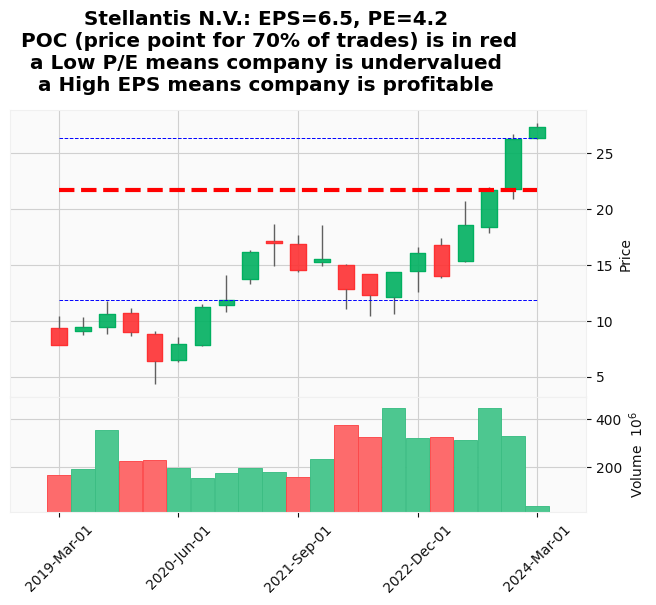

## Sector: Basic Materials

<Figure size 640x480 with 0 Axes>

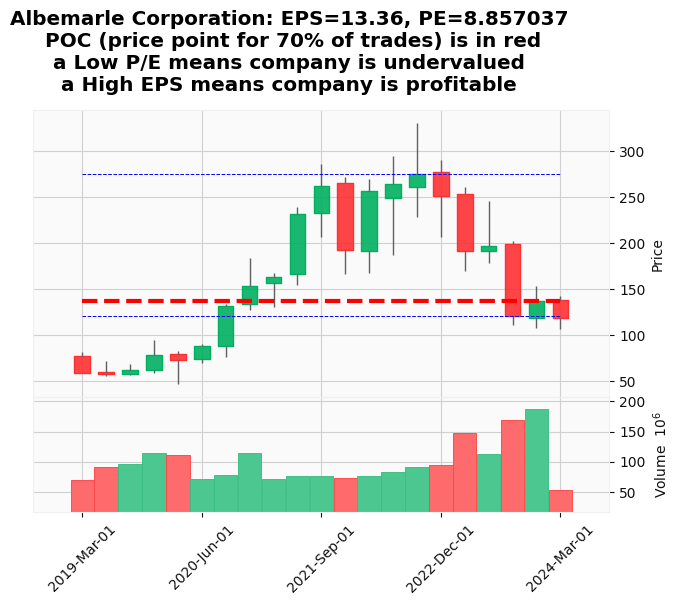

## Sector: Financial Services

<Figure size 640x480 with 0 Axes>

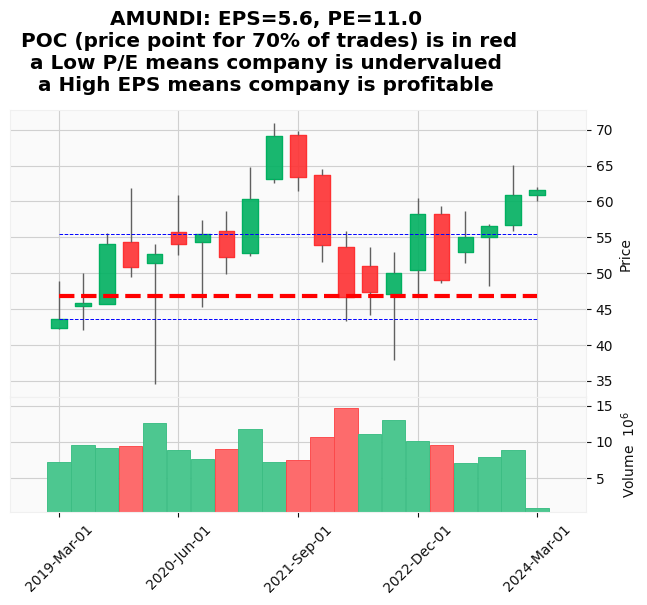

## Sector: Communication Services

<Figure size 640x480 with 0 Axes>

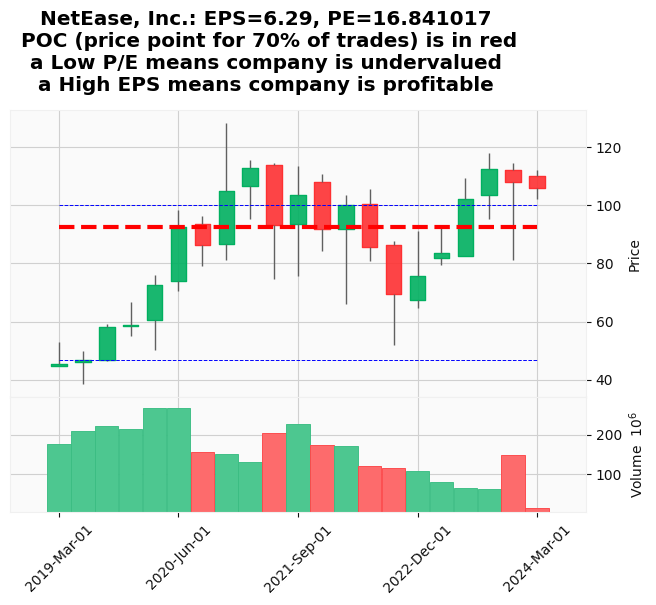

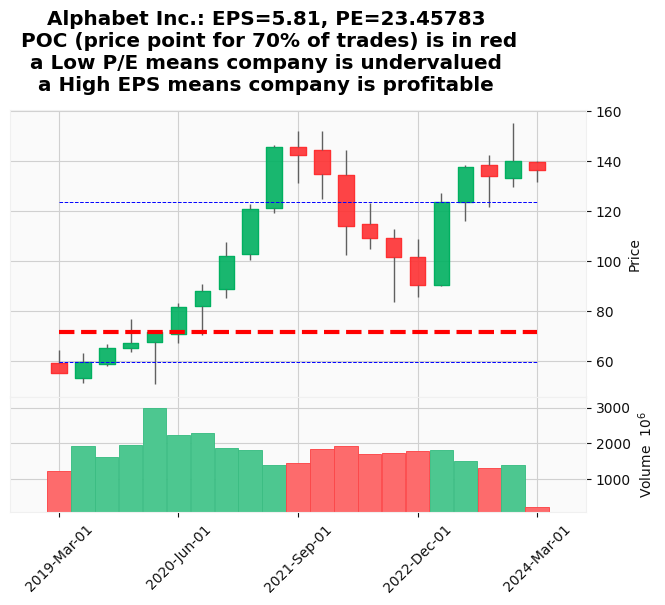

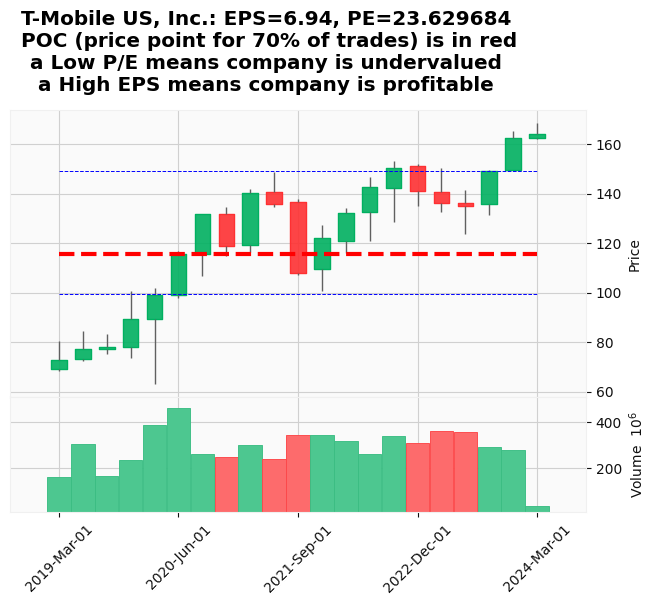

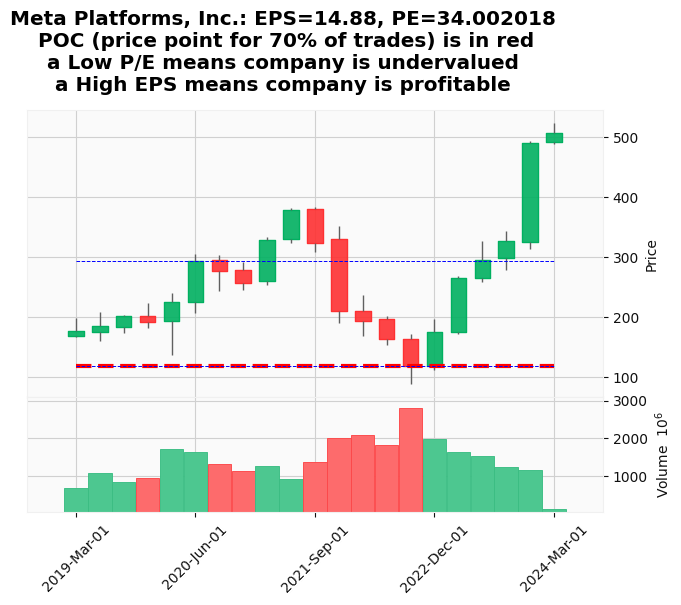

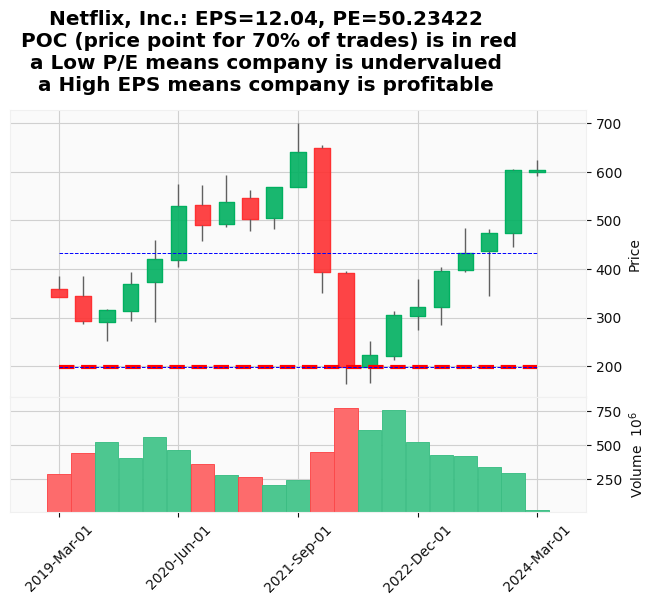

## Sector: Technology

<Figure size 640x480 with 0 Axes>

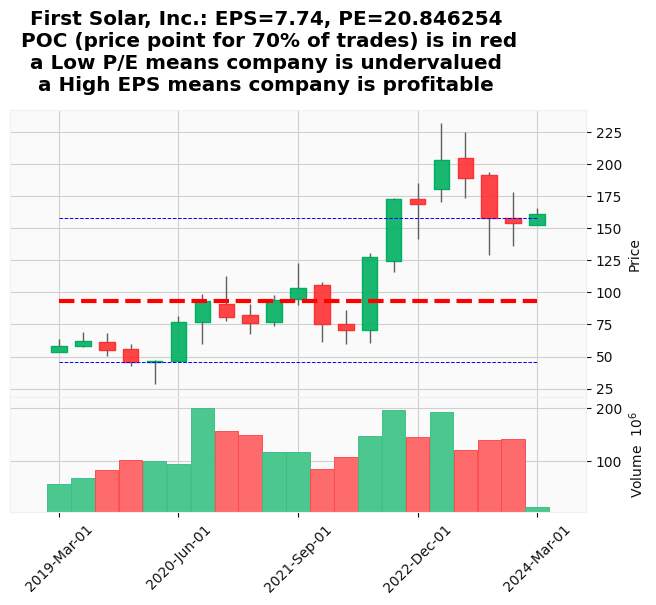

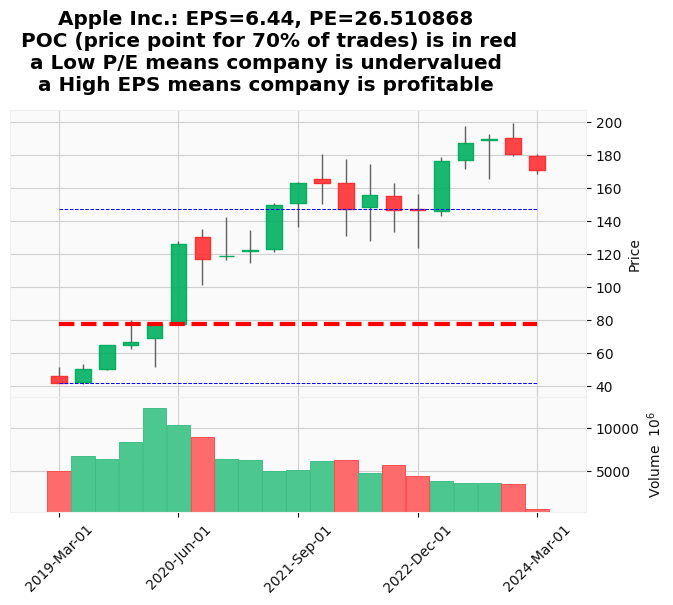

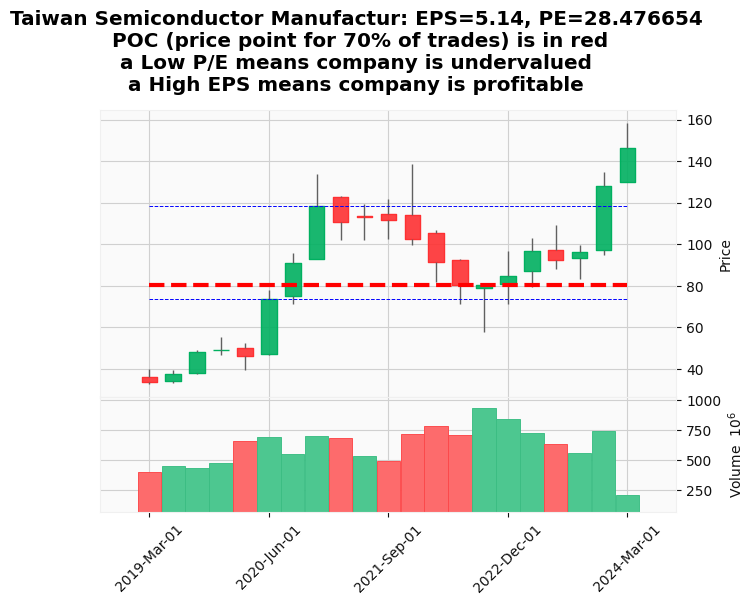

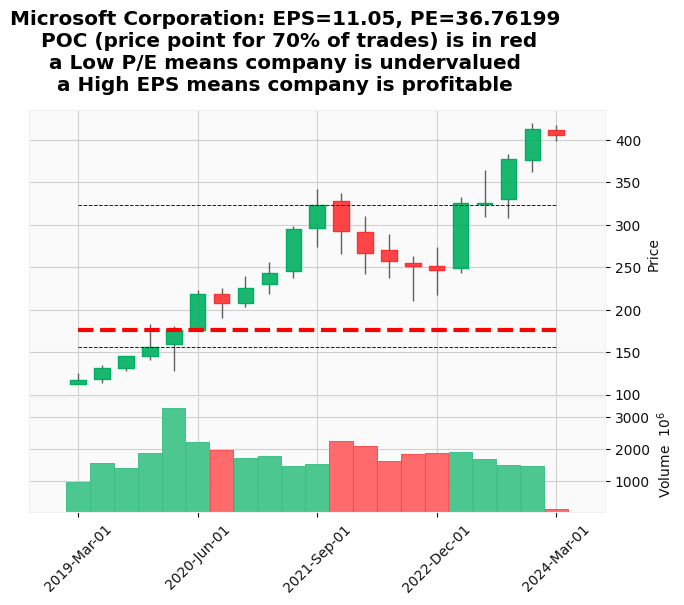

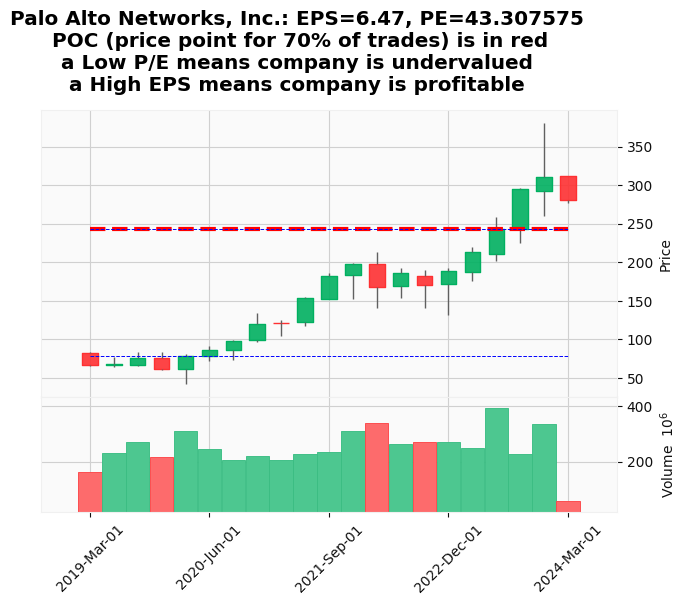

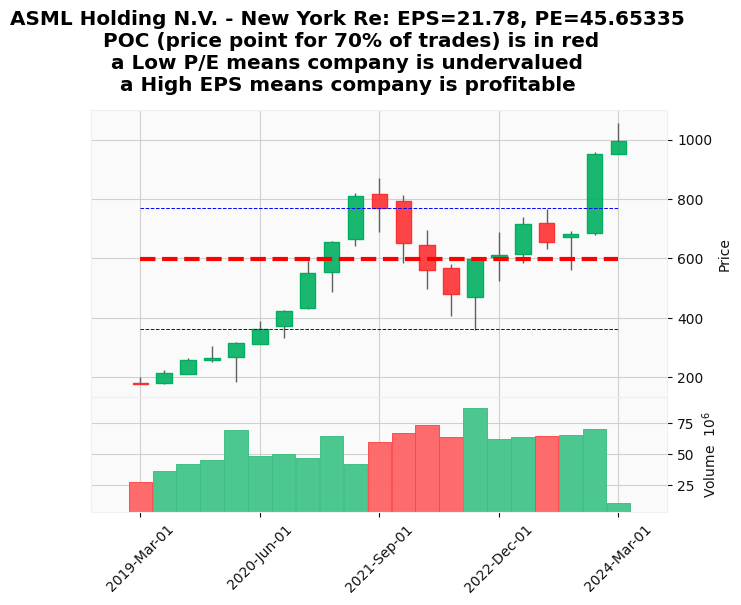

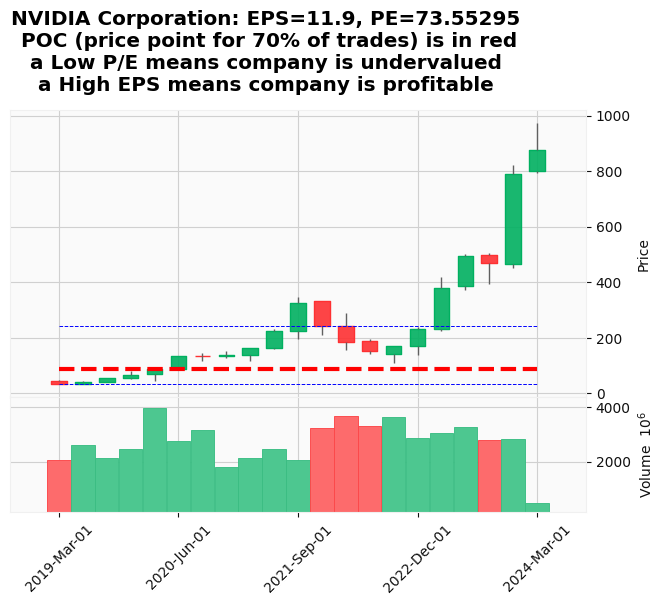

<Figure size 640x480 with 0 Axes>

In [20]:
plot_sector_charts(industries_filtered, start_date_str, end_date_str)